This notebook lets the user find the air exchanges per hour neccecary to limit the probability of infection (as calculated by CAiMIRA) below a predefined threashold.

In [9]:
from caimira.ventilation.ventilation import *
from caimira.ventilation.scenarios import *
from caimira.ventilation.get_models import *

In [10]:
scenario = scenarios.shared_office() # Scenarios tested: shared_office, classroom, patient_ward, ICU. No short range interactions.

lim_probability_infection_list = [0.1, 0.05]
lim_probability_infection = lim_probability_infection_list[0]

0 ACH   =>   P(I) = 12.74%, Dose = 8.01


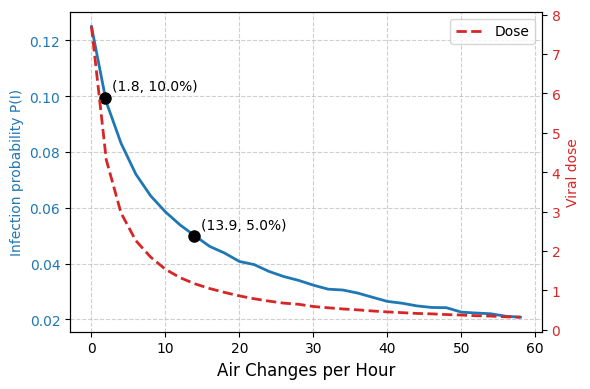

In [11]:
plot_probabilities(lim_probability_infection_list, scenario=scenario)

In [12]:
air_exch, probability = find_constant_air_exch(lim_probability_infection, scenario)

NOTE:

Variability between model runs may cause the probability of infection to be slightly higher than lim_probability_infection.

Inhaled dose:  4.5168 [0.0 - 21.0]
Probability of infection:  0.0999 [0.0 - 1.0]
Max average CO2: 1394.09
Air changes per hour: 1.78


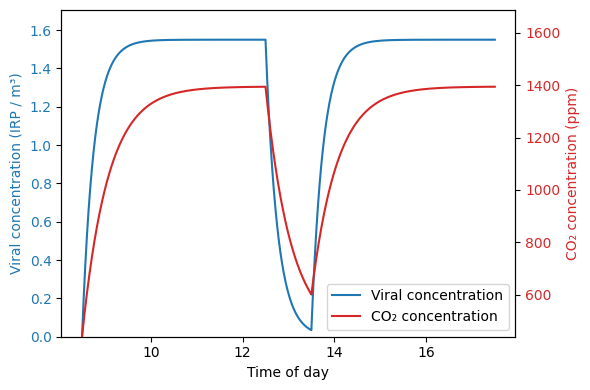

In [ ]:
plot_model_concentration_results(air_exch, scenario=scenario, deterministic_CO2=True)

In [14]:
air_exch_l, vent_transition_t = find_next_air_exch_by_co2(
    air_exch_list=[0.25],                                     # No ventilation
    vent_transition_times=[0,0.001],                          # Short interval to initialize the ventilation
    max_CO2=1400,                                             # Define a reasonable limit from the above plot (TODO: scale limit by number of occupants to make sense of scenarios where people come and go)
    scenario=scenario,
    min_CO2_fraction=0.9,                                     # Determines the lower limit for the CO2 concentration. Ventilation is decreased when reaching this point
    max_ventilation_changes=5 
)

In [15]:
for a, v in zip(air_exch_l, vent_transition_t):
    print(v, a)

0 0.25
0.001 2.105984007746841
10.300000000000068 1.0529920038734204
12.100000000000136 2.106299147701365
15.687000000000083 1.0531495738506824


NOTE: 

When the number of ventilation changes is defined as less than the model's number of state changes, the CO2 concentration may increase beyond the max CO2 limit (and similarly below the min CO2 limit). 

This also means that the probability of infection is not neccecarily <= lim_probability_infection. 

Inhaled dose:  4.8319 [0.0 - 23.0]
Probability of infection:  0.1032 [0.0 - 1.0]
Max average CO2: 1933.48
Air changes per hour: [0.25, np.float64(2.11), np.float64(1.05), np.float64(2.11), np.float64(1.05)]


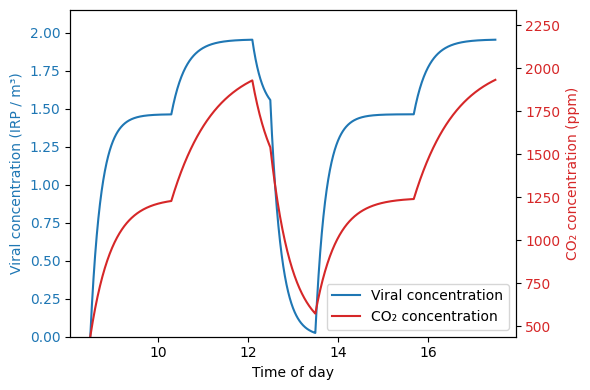

In [16]:
plot_model_concentration_results(air_exch_l, vent_transition_t, scenario=scenario, deterministic_CO2=True)